In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

In [5]:
titanic = pd.read_csv(url)


In [6]:
# 2. Use .info() — how many rows and columns does the dataset have?


titanic.info() 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# 3. Use .isnull().sum() to check for missing values. Which columns have missing data?

titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# 4. Fill missing Age values with the median age.

titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [9]:
# Drop the Cabin column (too many missing values to be useful).

titanic = titanic.drop('Cabin',axis=1)

In [10]:
# 6. Confirm there are no more missing values in the columns you fixed.

titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [ ]:
# 7. What is the overall survival rate? (Hint: titanic['Survived'].mean())

titanic['Survived'].mean

<bound method Series.mean of 0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64>

In [12]:
# 8. What is the survival rate for males vs females? Which group survived more?

titanic.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [13]:
# 9. What is the survival rate for each passenger class (1st, 2nd, 3rd)?

titanic.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [14]:
# 10. What is the average fare paid by each passenger class?

titanic.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Text(0.5, 1.0, 'Survival Count')

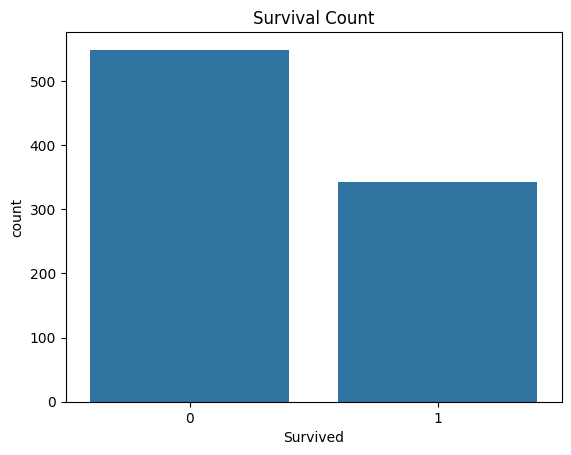

In [17]:
# 11. Create a countplot showing how many passengers survived vs did not survive.

sns.countplot(x = 'Survived', data = titanic)

plt.title('Survival Count')

Text(0.5, 1.0, 'Age distribution by survival')

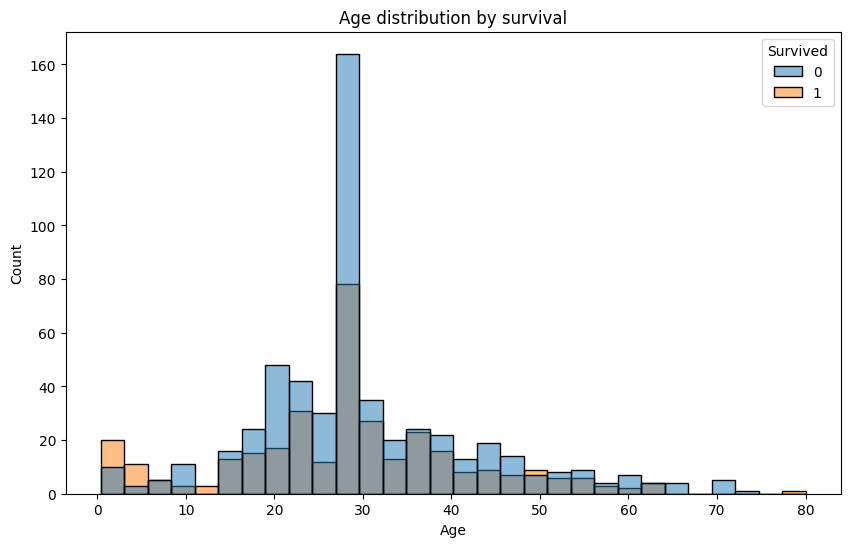

In [37]:
# 12. Create a histogram of passenger ages, with survivors and non-survivors in different colors.

plt.figure(figsize=(10,6))
sns.histplot(data = titanic, x = 'Age',hue ='Survived', bins = 30)

plt.title('Age distribution by survival')

Text(0.5, 1.0, 'Fare by Passenger Class')

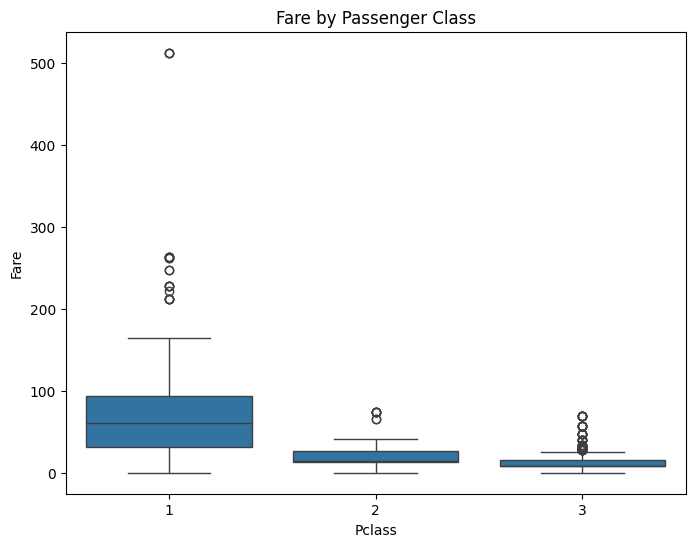

In [38]:
# 13. 13. Create a boxplot of fares grouped by passenger class.

plt.figure(figsize = (8, 6))
sns.boxplot(data = titanic, x = 'Pclass', y = 'Fare')
plt.title('Fare by Passenger Class')

In [ ]:
# 14. Which passengers were most likely to survive? List at least two factors from your analysis.

# Females were most likely to survive than males.
# First class passengersnhad higher survival rates.

In [ ]:
# 15. Why do you think 1st class passengers survived more than 3rd class?

# First class passengers probably survived more because they had better access to lifeboats and were treated with
# hgher priority during evacuation.

In [22]:
# 16. 16. Create a FamilySize column: SibSp + Parch + 1. 
# Did passengers with family survive more than those travelling alone?

titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

In [23]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1


In [24]:
# Comparison of Survivals

titanic['Alone'] = titanic['FamilySize'] == 1
titanic.groupby('Alone')['Survived'].mean()

Alone
False    0.505650
True     0.303538
Name: Survived, dtype: float64